In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [18]:
data = pd.read_csv("FeatureSelection_global_heat_index.csv")

clean1 = data[data['Hour']<6]
clean2 = data[data['Hour']>18]
data = data.drop(clean1.index, axis=0)
data = data.drop(clean2.index, axis=0)

x = data.iloc[:,4:-1].values
y = data.iloc[:,-1].values

y = y.reshape(-1,1)

from sklearn.preprocessing import StandardScaler
x = StandardScaler().fit_transform(x)
y = StandardScaler().fit_transform(y)

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=0)


In [20]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=6, random_state=0)
km = km.fit(x_train)
labels = km.labels_
print("labels : ",labels)
cluster_centers = km.cluster_centers_
print("cluster centers : ",cluster_centers)

c:\Users\sudhir\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


labels :  [4 5 3 ... 0 4 4]
cluster centers :  [[-0.64802814 -1.65457752  1.18515822  0.25986525 -1.09803182 -0.01763892]
 [ 0.14822165 -0.38319629  0.65289574  0.19224436  0.68491062 -0.78439163]
 [ 0.40182189  1.05332018 -1.08153934 -0.40766387  0.50413271  1.50660685]
 [-1.06069781  0.69722567  0.0431936  -1.16338307  0.8243205   0.02529222]
 [ 1.18274349  0.06948464 -0.9375015   1.26641527  0.2485424  -0.08600816]
 [-0.61004571 -0.23350537  0.85758317 -0.56999168 -1.35073796 -0.68846656]]


### Applying PCA - Dimensionality Reduction

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2).fit(x_train).transform(x_train)

In [23]:
pca

array([[-1.58492642, -1.06028458],
       [ 1.23529976,  0.28911478],
       [-0.82397779,  2.06667306],
       ...,
       [ 2.89426021, -0.67736503],
       [-1.29307872, -2.03889935],
       [-1.53091671, -1.64434646]])

In [29]:
legend_labels = set(labels)
legend_labels

{0, 1, 2, 3, 4, 5}

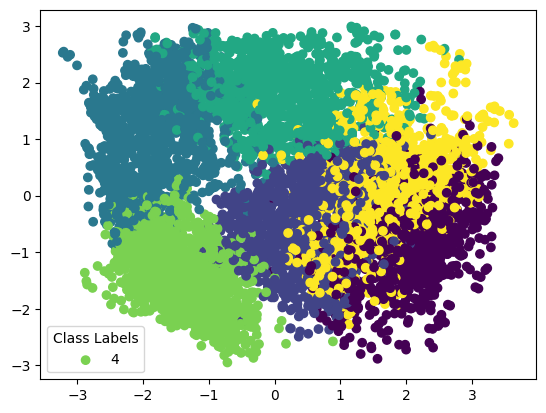

In [49]:
plt.scatter(pca[:,0],pca[:,1], c=labels)
plt.legend(pd.DataFrame(labels)[0].unique(), title='Class Labels')
plt.show()
# plt.scatter(centres[:,0],centres[:,1], c='black', marker='^')